In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("FINAL_DATASET_PREDICTION_CEjour.csv")

In [15]:
df.isnull().sum()

DATE              0
WELL              0
HOURS             0
WHP               0
WHT               0
W_GAS             0
WATER             0
COND_VOL          0
DELTA_DAYS        0
WHP_LAG_1        89
WHT_LAG_1        89
GAS_LAG_1        89
WATER_LAG_1      89
COND_LAG_1       89
WHP_LAG_3       267
WHT_LAG_3       267
GAS_LAG_3       267
WATER_LAG_3     267
COND_LAG_3      267
WHP_LAG_7       623
WHT_LAG_7       623
GAS_LAG_7       623
WATER_LAG_7     623
COND_LAG_7      623
GAS_MEAN_3      178
GAS_MEAN_7      534
WATER_MEAN_3    178
WATER_MEAN_7    534
COND_MEAN_3     178
COND_MEAN_7     534
DAY               0
MONTH             0
DAY_OF_WEEK       0
dtype: int64

In [2]:
features = [
    "WHP","WHT",

    "WHP_LAG_1","WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_1","WHT_LAG_3","WHT_LAG_7",

    "GAS_LAG_1","GAS_LAG_3","GAS_LAG_7",
    "WATER_LAG_1","WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_1","COND_LAG_3","COND_LAG_7",

    "GAS_MEAN_3","GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_MEAN_3","COND_MEAN_7",

    "DAY","MONTH","DAY_OF_WEEK"
]

target = ["W_GAS","WATER","COND_VOL"]

In [3]:
split_date = "2018-01-01"

train = df[df["DATE"] <= split_date]
test  = df[df["DATE"] >  split_date]


X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [4]:

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

In [5]:

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [6]:
y_pred = model.predict(X_test)

test["PRED_GAS"]   = y_pred[:,0]
test["PRED_WATER"] = y_pred[:,1]
test["PRED_COND"]  = y_pred[:,2]


In [7]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 :", r2)

MAE: 0.30774126445409417
R2 : 0.9747711914123257


In [8]:
prediction_par_puit = (
    test.groupby("WELL")[[
        "W_GAS","PRED_GAS",
        "WATER","PRED_WATER",
        "COND_VOL","PRED_COND"
    ]]
    .sum()
)

print(prediction_par_puit.head())

              W_GAS    PRED_GAS        WATER   PRED_WATER      COND_VOL  \
WELL                                                                      
TFT-302   95.392044   95.293732   778.547166   780.473818   9628.459474   
TFT-304   31.567936   31.308312     0.000000     2.631805   5613.182388   
TFT-306   51.229123   51.229276     3.996699     8.032986  11638.736669   
TFT-308   13.514430   13.297882     0.000000     1.419547   2765.994593   
TFT-310  197.357407  197.395272  3230.965668  3221.816813  21053.222969   

            PRED_COND  
WELL                   
TFT-302   9613.750031  
TFT-304   5555.084071  
TFT-306  11613.632805  
TFT-308   2719.099380  
TFT-310  21085.782224  


In [9]:
production_zone = (
    test.groupby("DATE")[[
        "W_GAS","PRED_GAS",
        "WATER","PRED_WATER",
        "COND_VOL","PRED_COND"
    ]]
    .sum()
)

print(production_zone.tail())

               W_GAS  PRED_GAS       WATER  PRED_WATER     COND_VOL  \
DATE                                                                  
2020-02-25  8.529596  8.453130  107.443011  107.233768  1176.564113   
2020-02-26  8.501818  8.391272  107.188749  106.564372  1172.498943   
2020-02-27  8.254614  8.427162  105.989087  106.690577  1144.776129   
2020-02-28  7.210964  7.567543   97.390627  100.729897   994.241851   
2020-02-29  8.064910  8.164750  106.134398  106.187967  1111.852902   

              PRED_COND  
DATE                     
2020-02-25  1165.759189  
2020-02-26  1153.529122  
2020-02-27  1171.010824  
2020-02-28  1047.749215  
2020-02-29  1123.567820  


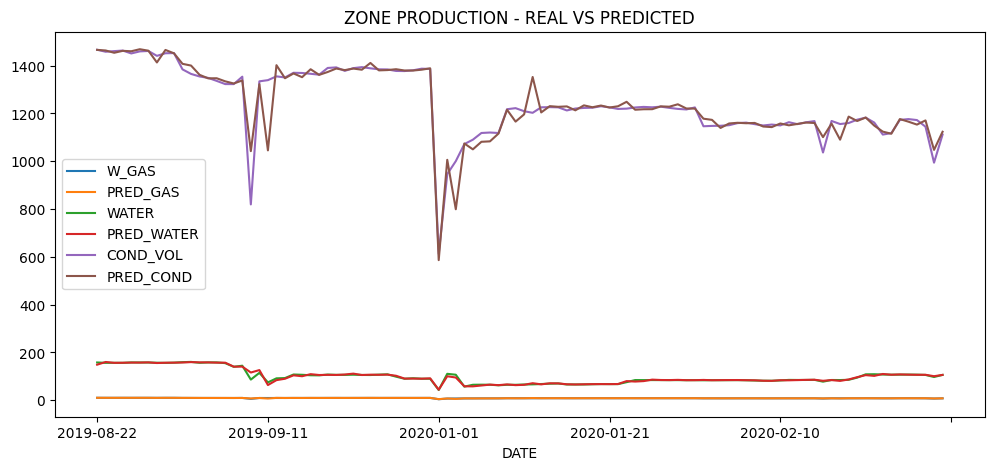

In [10]:
production_zone.tail(100).plot(figsize=(12,5))
plt.title("ZONE PRODUCTION - REAL VS PREDICTED")
plt.show()